# Notebook 1 Ã¢â‚¬â€ Data Ingestion
**Deadline:** Mar 1 (Weeks 1Ã¢â‚¬â€œ6)  
**Goal:** Load GEFS + ERA5 weather data and EAGLE-I outage data Ã¢â‚¬â€ all free, no credentials required.

---

## Data Sources

| Dataset | Format | Access | Cost |
|---|---|---|---|
| **GEFS Analysis** (wind, precip, RH) | **Zarr v3** via dynamical.org | `https://data.dynamical.org/noaa/gefs/analysis/latest.zarr` | Free, no credentials |
| **ERA5 Reanalysis** (CAPE, soil moisture, wind gust) | **Zarr** via ARCO-ERA5 (Google Cloud) | `gs://gcp-public-data-arco-era5/...` | Free, anonymous |
| **EAGLE-I Outages** | CSV | DOE figshare DOI | Free |
| **US County Shapefile** | Shapefile | US Census TIGER | Free |

### Why two weather sources?
- **dynamical.org GEFS** provides wind (u/v 10m), precipitation, precipitable water, RH, and temperature in clean Zarr v3 / IceChunk format covering 2000Ã¢â‚¬â€œpresent.
- **ARCO-ERA5** fills the critical gaps: **CAPE, CIN, soil moisture, and wind gusts** Ã¢â‚¬â€ variables not available in the dynamical.org GEFS analysis but essential to the Hill et al. / Saki et al. methodology.

> Ã¢Å¡Â Ã¯Â¸Â **IceChunk note:** dynamical.org's IceChunk URLs are pre-release. Subscribe to their newsletter for any URL changes when IceChunk 2.0 is released.

---

In [14]:
# ============================================================
# INSTALL ZARR / ICECHUNK PACKAGES
# Run once, then restart kernel
# ============================================================
import subprocess, sys

zarr_packages = [
    "zarr>=3.0.8",
    "xarray>=2025.1.2",
    "icechunk",
    "gcsfs",
    "fsspec",
    "aiohttp",
    "dask",
]
for pkg in zarr_packages:
    result = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], capture_output=True, text=True)
    print(f"  {'Ã¢Å“â€œ' if result.returncode == 0 else 'Ã¢Å“â€”'}  {pkg}")
print("\nDone. Restart kernel if first run.")

  Ã¢Å“â€œ  zarr>=3.0.8
  Ã¢Å“â€œ  xarray>=2025.1.2
  Ã¢Å“â€œ  icechunk
  Ã¢Å“â€œ  gcsfs
  Ã¢Å“â€œ  fsspec
  Ã¢Å“â€œ  aiohttp
  Ã¢Å“â€œ  dask

Done. Restart kernel if first run.


In [15]:
# ============================================================
# IMPORTS & CONFIG
# ============================================================
import os, json, zipfile, warnings
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import gcsfs
import matplotlib.pyplot as plt
import xarray as xr
from tqdm import tqdm

warnings.filterwarnings("ignore")

# Ã¢â€ Â EDIT THIS to your project folder
PROJECT_ROOT = Path(r"C:\Users\tomy3\Capstone2026\Testingthings") #(Since Working Localy right now) Path("/data/keeling/a/tob3/Capstone2026/Testingthings")

DATA_RAW      = PROJECT_ROOT / "data" / "raw"
DATA_PROC     = PROJECT_ROOT / "data" / "processed"
EAGLEI_DIR    = DATA_RAW / "eaglei"
COUNTY_SHP    = DATA_RAW / "counties"

CONUS_FIPS = [
    "01","04","05","06","08","09","10","11","12","13",
    "16","17","18","19","20","21","22","23","24","25",
    "26","27","28","29","30","31","32","33","34","35",
    "36","37","38","39","40","41","42","44","45","46",
    "47","48","49","50","51","53","54","55","56"
]
REGION5_FIPS = ["17", "18", "26", "27", "39", "55"]  # kept for pilot compatibility
DOMAIN_LAT   = (24.5, 49.5)
DOMAIN_LON   = (-125.0, -66.5)
TRAIN_YEARS = list(range(2014, 2024))
TEST_YEARS  = [2024]
OUTAGE_THRESHOLD = 0.01

for d in [DATA_RAW, DATA_PROC, EAGLEI_DIR, COUNTY_SHP]:
    d.mkdir(parents=True, exist_ok=True)

print("Config loaded. Project root:", PROJECT_ROOT)

Config loaded. Project root: C:\Users\tomy3\Capstone2026\Testingthings


In [16]:
print(dir())

['API_BASE', 'ARTICLE_ID', 'CONUS_FIPS', 'COUNTY_SHP', 'COUNTY_URL', 'COUNTY_ZIP', 'CUSTOMERS_OUT_THRESHOLD', 'DATA_PROC', 'DATA_RAW', 'DOMAIN_LAT', 'DOMAIN_LON', 'EAGLEI_DIR', 'In', 'OUTAGE_THRESHOLD', 'Out', 'PROJECT_ROOT', 'Path', 'REGION5_FIPS', 'TEST_YEARS', 'TRAIN_YEARS', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_existing', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', '_out', 'abbr', 'all_files', 'bar', 'batch', 'chunk', 'cond', 'counties_all', 'counties_conus', 'counties_r5', 'county_code', 'county_forest', 'd', 'dest', 'df', 'df_test', 'download_file', 'eaglei_urls', 'exit', 'f', 'f_out', 'fips', 'frames', 'gcsfs', 'get_ipython', 'gpd', 'io', 'json', 'line', 'monthly', 'normals_avg', 'normals_df', 'normals_url', 'np', 'open', 'os', 'page', 'parts', 'pd', 'pkg', 'plt', 'q

---
## Part 1 Ã¢â‚¬â€ US County Shapefile

In [17]:
import os
COUNTY_URL = "https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip"
COUNTY_ZIP = COUNTY_SHP / "tl_2022_us_county.zip"
def download_file(url, dest, chunk_size=1 << 20):
    if dest.exists():
        # Verify it's a valid zip before skipping
        if dest.suffix == ".zip":
            try:
                with zipfile.ZipFile(dest) as zf:
                    zf.testzip()
                print(f"  Already exists and valid: {dest.name}")
                return
            except zipfile.BadZipFile:
                print(f"  Corrupted zip found, re-downloading: {dest.name}")
                dest.unlink()  # delete the bad file
        else:
            print(f"  Already exists: {dest.name}")
            return
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    total = int(r.headers.get("content-length", 0))
    with open(dest, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=dest.name) as bar:
        for chunk in r.iter_content(chunk_size):
            f.write(chunk); bar.update(len(chunk))

download_file(COUNTY_URL, COUNTY_ZIP)
with zipfile.ZipFile(COUNTY_ZIP) as zf:
    zf.extractall(COUNTY_SHP)

counties_all = gpd.read_file(COUNTY_SHP / "tl_2022_us_county.shp")

# CONUS counties
counties_conus = counties_all[counties_all["STATEFP"].isin(CONUS_FIPS)].copy().to_crs(epsg=4326)
counties_conus["centroid_lon"] = counties_conus.geometry.centroid.x
counties_conus["centroid_lat"] = counties_conus.geometry.centroid.y
counties_conus.to_file(COUNTY_SHP / "counties_conus.gpkg", driver="GPKG")
print(f"CONUS counties: {len(counties_conus)}")

# Keep Region 5 file for pilot compatibility
counties_r5 = counties_conus[counties_conus["STATEFP"].isin(REGION5_FIPS)].copy()
counties_r5.to_file(COUNTY_SHP / "counties_region5.gpkg", driver="GPKG")
print(f"FEMA Region 5 counties: {len(counties_r5)}")

  Already exists and valid: tl_2022_us_county.zip
CONUS counties: 3109
FEMA Region 5 counties: 524


---
## Part 2 Ã¢â‚¬â€ EAGLE-I Outage Data

In [18]:
import requests
from tqdm import tqdm

# ============================================================
# EAGLE-I: figshare API with pagination + download + filter
# ============================================================

ARTICLE_ID = 24237376
API_BASE = f"https://api.figshare.com/v2/articles/{ARTICLE_ID}/files"

print("Fetching full file list from figshare API...")
all_files = []
page = 1
while True:
    r = requests.get(API_BASE, params={"page": page, "page_size": 100}, timeout=30)
    r.raise_for_status()
    batch = r.json()
    if not batch:
        break
    all_files.extend(batch)
    page += 1

print(f"Total files found: {len(all_files)}")

# Find annual CSVs
target_years = list(range(2014, 2025))
eaglei_urls = {}
for f in all_files:
    for yr in target_years:
        if f"eaglei_outages_{yr}" in f["name"]:
            eaglei_urls[yr] = f["download_url"]
            print(f"  Ã¢Å“â€œ Found {yr}: {f['name']}")

# Download and filter
eaglei_frames = []
for yr, url in eaglei_urls.items():
    dest = EAGLEI_DIR / f"eaglei_outages_{yr}.csv"

    # Delete if empty or corrupted
    if dest.exists() and dest.stat().st_size < 1000:
        print(f"  Removing bad file: {dest.name}")
        dest.unlink()

    if not dest.exists():
        print(f"\nDownloading {yr}...")
        r = requests.get(url, stream=True, timeout=120)
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(dest, "wb") as f_out, tqdm(total=total, unit="B", unit_scale=True) as bar:
            for chunk in r.iter_content(1 << 20):
                f_out.write(chunk); bar.update(len(chunk))
    else:
        print(f"  Already exists: {dest.name} ({dest.stat().st_size / 1e6:.1f} MB)")

    df = pd.read_csv(dest, parse_dates=["run_start_time"], low_memory=False)
    df.columns = df.columns.str.lower().str.strip()

    # Normalize column name Ã¢â‚¬â€ older files use 'customers_out', newer use 'sum'
    if "sum" in df.columns and "customers_out" not in df.columns:
        df = df.rename(columns={"sum": "customers_out"})

    df["fips_str"]   = df["fips_code"].astype(str).str.zfill(5)
    df["state_fips"] = df["fips_str"].str[:2]
    df = df[df["state_fips"].isin(CONUS_FIPS)].copy()

    CUSTOMERS_OUT_THRESHOLD = 100
    df["outage_event"] = (df["customers_out"] >= CUSTOMERS_OUT_THRESHOLD).astype(int)

    eaglei_frames.append(df)
    print(f"  {yr}: {len(df):,} rows | outage events: {df['outage_event'].sum():,} ({df['outage_event'].mean()*100:.1f}%)")

eaglei_all = pd.concat(eaglei_frames, ignore_index=True).sort_values("run_start_time")
eaglei_all.to_parquet(DATA_RAW / "eaglei_conus_all.parquet", index=False)
print(f"\nSaved {len(eaglei_all):,} total records.")
del eaglei_frames  # free per-year DataFrames (~few hundred MB)
del eaglei_all     # free 213M-row DataFrame â€” already saved to parquet
print('RAM freed.')

Fetching full file list from figshare API...
Total files found: 17
  Ã¢Å“â€œ Found 2014: eaglei_outages_2014.csv
  Ã¢Å“â€œ Found 2015: eaglei_outages_2015.csv
  Ã¢Å“â€œ Found 2016: eaglei_outages_2016.csv
  Ã¢Å“â€œ Found 2017: eaglei_outages_2017.csv
  Ã¢Å“â€œ Found 2018: eaglei_outages_2018.csv
  Ã¢Å“â€œ Found 2019: eaglei_outages_2019.csv
  Ã¢Å“â€œ Found 2020: eaglei_outages_2020.csv
  Ã¢Å“â€œ Found 2021: eaglei_outages_2021.csv
  Ã¢Å“â€œ Found 2022: eaglei_outages_2022.csv
  Ã¢Å“â€œ Found 2023: eaglei_outages_2023.csv
  Ã¢Å“â€œ Found 2024: eaglei_outages_2024.csv
  Already exists: eaglei_outages_2014.csv (78.1 MB)
  2014: 1,689,460 rows | outage events: 210,661 (12.5%)
  Already exists: eaglei_outages_2015.csv (599.0 MB)
  2015: 12,932,982 rows | outage events: 1,660,832 (12.8%)
  Already exists: eaglei_outages_2016.csv (619.8 MB)
  2016: 13,293,095 rows | outage events: 1,767,961 (13.3%)
  Already exists: eaglei_outages_2017.csv (698.8 MB)
  2017: 15,022,158 rows | outage events: 2

In [19]:
df_test = pd.read_csv(EAGLEI_DIR / "eaglei_outages_2023.csv", nrows=5, low_memory=False)
print(df_test.columns.tolist())
print(df_test.head())


['fips_code', 'county', 'state', 'sum', 'run_start_time']
   fips_code    county    state  sum       run_start_time
0       1003   Baldwin  Alabama    1  2023-01-01 00:00:00
1       1011   Bullock  Alabama    9  2023-01-01 00:00:00
2       1015   Calhoun  Alabama    4  2023-01-01 00:00:00
3       1021   Chilton  Alabama    4  2023-01-01 00:00:00
4       1029  Cleburne  Alabama  142  2023-01-01 00:00:00


In [20]:
# ============================================================
# NOAA nClimDiv 30-Year County Precipitation Normals
# Pre-computed 1991-2020 normals, county level, Jan-Dec
# Used in notebook 02 to compute precipitation anomaly feature
# ============================================================
import requests, io

print("Downloading NOAA nClimDiv county precipitation normals...")
normals_url = "https://www.ncei.noaa.gov/pub/data/cirs/climdiv/climdiv-norm-pcpncy-v1.0.0-20260406"

r = requests.get(normals_url, timeout=60)
r.raise_for_status()

# Parse fixed-width format: county_code + 12 monthly normals
rows = []
for line in r.text.strip().split("\n"):
    parts = line.split()
    if len(parts) == 13:
        county_code = parts[0]
        monthly = [float(x) for x in parts[1:]]
        rows.append([county_code] + monthly)

normals_df = pd.DataFrame(rows, columns=[
    "county_code", "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
])

# The county code format is SSCCCYYYY Ã¢â‚¬â€ first 2=state, next 3=county, last 4=element/year
# Extract state+county FIPS (first 5 digits)
normals_df["fips"] = normals_df["county_code"].str[:5].apply(
    lambda x: f"{int(x[:2]):02d}{int(x[2:5]):03d}"
)

normals_df = normals_df.drop(columns=["county_code"])
normals_df.to_parquet(DATA_PROC / "county_precip_normals.parquet", index=False)

print(f"Normals saved: {normals_df.shape}")
print(f"FIPS sample: {normals_df['fips'].head().tolist()}")
print(normals_df.head())

Normals saved: (37499, 13)
FIPS sample: ['01001', '01001', '01001', '01001', '01001']
    jan   feb   mar   apr   may   jun   jul   aug   sep   oct   nov   dec  \
0  5.15  5.50  5.87  4.28  4.11  3.68  5.07  4.23  3.45  2.44  3.36  5.09   
1  5.57  5.20  5.72  4.87  3.64  3.71  5.42  4.91  3.19  2.63  3.19  5.22   
2  5.18  5.26  6.29  4.97  3.93  4.06  5.42  4.67  3.03  2.12  3.72  4.88   
3  4.57  5.06  6.19  5.47  3.97  3.92  5.37  4.47  3.29  2.19  3.25  4.87   
4  4.44  5.22  6.34  5.40  3.74  4.21  5.09  3.92  3.71  2.35  3.63  5.18   

    fips  
0  01001  
1  01001  
2  01001  
3  01001  
4  01001  


In [21]:
# Average multiple rows per FIPS to get one normal per county
normals_avg = normals_df.groupby("fips")[
    ["jan","feb","mar","apr","may","jun",
     "jul","aug","sep","oct","nov","dec"]
].mean().reset_index()

normals_avg.to_parquet(DATA_PROC / "county_precip_normals.parquet", index=False)
print(f"Averaged normals: {normals_avg.shape}")
print(f"Unique FIPS: {normals_avg['fips'].nunique()}")
print(normals_avg.head())

Averaged normals: (3142, 13)
Unique FIPS: 3142
    fips       jan       feb       mar       apr       may       jun  \
0  01001  5.088333  5.239167  6.103333  4.885833  3.920833  4.073333   
1  01003  4.796667  4.936667  6.081667  4.711667  4.495000  5.550000   
2  01005  4.746667  4.795833  5.737500  4.341667  3.825000  4.245833   
3  01007  5.444167  5.323333  6.265000  5.010833  4.217500  4.214167   
4  01009  5.499167  5.214167  6.183333  5.007500  4.431667  4.035000   

        jul       aug       sep       oct       nov       dec  
0  5.179167  4.170000  3.649167  2.633333  3.763333  5.095000  
1  7.325833  6.216667  5.762500  3.432500  3.832500  4.961667  
2  5.604167  4.583333  3.800000  2.560833  3.425000  4.767500  
3  5.145000  4.140833  3.508333  2.854167  3.984167  5.199167  
4  4.902500  4.116667  3.673333  3.122500  4.175833  5.294167  


In [22]:
# ============================================================
# FIA COUNTY FOREST FRACTION Ã¢â‚¬â€ real county-level forest cover
# Computed from USDA FIA COND table for Region 5 states
# ============================================================
import requests, io

states = {
    "AL":"01","AZ":"04","AR":"05","CA":"06","CO":"08","CT":"09","DE":"10",
    "FL":"12","GA":"13","ID":"16","IL":"17","IN":"18","IA":"19",
    "KS":"20","KY":"21","LA":"22","ME":"23","MD":"24","MA":"25","MI":"26",
    "MN":"27","MS":"28","MO":"29","MT":"30","NE":"31","NV":"32","NH":"33",
    "NJ":"34","NM":"35","NY":"36","NC":"37","ND":"38","OH":"39","OK":"40",
    "OR":"41","PA":"42","RI":"44","SC":"45","SD":"46","TN":"47","TX":"48",
    "UT":"49","VT":"50","VA":"51","WA":"53","WV":"54","WI":"55","WY":"56"
}
frames = []

for abbr, fips in states.items():
    print(f"Downloading FIA COND for {abbr}...")
    url = f"https://apps.fs.usda.gov/fia/datamart/CSV/{abbr}_COND.csv"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    df = pd.read_csv(io.StringIO(r.text), usecols=["STATECD","COUNTYCD","COND_STATUS_CD","CONDPROP_UNADJ"])
    frames.append(df)

cond = pd.concat(frames, ignore_index=True)

cond["forested"] = (cond["COND_STATUS_CD"] == 1).astype(float) * cond["CONDPROP_UNADJ"].fillna(0)
cond["total"] = cond["CONDPROP_UNADJ"].fillna(0)

county_forest = cond.groupby(["STATECD","COUNTYCD"]).agg(
    forest=("forested","sum"),
    total=("total","sum")
).reset_index()

county_forest["forest_fraction"] = county_forest["forest"] / county_forest["total"]

In [23]:
county_forest["forest_fraction"] = county_forest["forest"] / county_forest["total"]
county_forest["fips"] = (
    county_forest["STATECD"].astype(str).str.zfill(2)
    + county_forest["COUNTYCD"].astype(str).str.zfill(3)
)
county_forest.to_parquet(DATA_PROC / "county_forest_fraction.parquet", index=False)
print(f"Saved forest fraction for {len(county_forest)} counties")

Saved forest fraction for 3073 counties


In [24]:
# ============================================================
# NOAA NClimDiv COUNTY PRECIP NORMALS Ã¢â‚¬â€ full CONUS coverage
# Cell-9 already produced county_precip_normals.parquet (3142 counties).
# This cell recomputes from raw annual data only if the file is missing.
# ============================================================
import requests, io, re

_out = DATA_PROC / "county_precip_normals.parquet"
if _out.exists():
    _existing = pd.read_parquet(_out)
    print(f"county_precip_normals.parquet already exists ({len(_existing)} counties) Ã¢â‚¬â€ skipping.")
else:
    print("Downloading NOAA NClimDiv county precipitation (raw annual)...")
    NCLIMDIV_TO_FIPS = {
        1:"01",2:"04",3:"05",4:"06",5:"08",6:"09",7:"10",8:"12",9:"13",
        10:"16",11:"17",12:"18",13:"19",14:"20",15:"21",16:"22",17:"23",
        18:"24",19:"25",20:"26",21:"27",22:"28",23:"29",24:"30",25:"31",
        26:"32",27:"33",28:"34",29:"35",30:"36",31:"37",32:"38",33:"39",
        34:"40",35:"41",36:"42",37:"44",38:"45",39:"46",40:"47",41:"48",
        42:"49",43:"50",44:"51",45:"53",46:"54",47:"55",48:"56",
    }
    idx_url = "https://www.ncei.noaa.gov/pub/data/cirs/climdiv/"
    r = requests.get(idx_url, timeout=30)
    dates = re.findall(r'climdiv-pcpncy-v1\.0\.0-(\d{8})', r.text)
    latest = max(dates) if dates else "20260406"
    url = f"https://www.ncei.noaa.gov/pub/data/cirs/climdiv/climdiv-pcpncy-v1.0.0-{latest}"
    print(f"  Fetching: climdiv-pcpncy-v1.0.0-{latest}")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    lines = r.text.strip().splitlines()
    print(f"  Total lines: {len(lines):,}")
    print("  First 3 lines:")
    for ln in lines[:3]:
        parts = ln.split()
        print(f"    {len(parts)} fields | code={parts[0]!r} len={len(parts[0])}")
    MONTHS = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
    records = []
    for line in lines:
        parts = line.split()
        if len(parts) < 13:
            continue
        code = parts[0]
        if len(code) < 7:
            continue
        try:
            st_code = int(code[:2])
            co_code = code[2:5]
            year    = int(code[-4:])
        except ValueError:
            continue
        if st_code not in NCLIMDIV_TO_FIPS:
            continue
        fips = NCLIMDIV_TO_FIPS[st_code] + co_code.zfill(3)
        try:
            vals = [float(x) if float(x) != -9999.0 else float("nan") for x in parts[1:13]]
        except ValueError:
            continue
        records.append({"fips": fips, "year": year, **dict(zip(MONTHS, vals))})
    if not records:
        print("WARNING: parser matched 0 lines Ã¢â‚¬â€ falling back to pre-computed normals...")
        fallback_url = f"https://www.ncei.noaa.gov/pub/data/cirs/climdiv/climdiv-norm-pcpncy-v1.0.0-{latest}"
        r2 = requests.get(fallback_url, timeout=60)
        r2.raise_for_status()
        rows = []
        for line in r2.text.strip().split("\n"):
            p = line.split()
            if len(p) == 13:
                rows.append([p[0]] + [float(x) for x in p[1:]])
        normals_df = pd.DataFrame(rows, columns=["county_code"] + MONTHS)
        normals_df["fips"] = normals_df["county_code"].str[:5].apply(
            lambda x: f"{int(x[:2]):02d}{int(x[2:5]):03d}"
        )
        normals_avg = normals_df.drop(columns=["county_code"]).groupby("fips")[MONTHS].mean().reset_index()
        normals_avg.to_parquet(_out, index=False)
        print(f"  Saved (fallback): {len(normals_avg)} counties")
    else:
        raw = pd.DataFrame(records)
        print(f"  Parsed {len(raw):,} records ({raw['year'].min()}-{raw['year'].max()})")
        normals = raw[raw["year"].between(1991, 2020)].groupby("fips")[MONTHS].mean().reset_index()
        normals.to_parquet(_out, index=False)
        print(f"  Normals saved for {len(normals)} counties")


county_precip_normals.parquet already exists (3142 counties) Ã¢â‚¬â€ skipping.


In [25]:
for f in all_files:
    print(repr(f["name"]))
    

'eaglei_outages_2025.csv'
'DQI.csv'
'MCC.csv'
'coverage_history.csv'
'eaglei_outages_2014.csv'
'eaglei_outages_2015.csv'
'eaglei_outages_2016.csv'
'eaglei_outages_2017.csv'
'eaglei_outages_2018.csv'
'eaglei_outages_2019.csv'
'eaglei_outages_2020.csv'
'eaglei_outages_2021.csv'
'eaglei_outages_2022.csv'
'eaglei_outages_2023.csv'
'Uri_Map.R'
'DQI_processing.R'
'eaglei_outages_2024.csv'


---
## Part 3 Ã¢â‚¬â€ GEFS Analysis via dynamical.org (Zarr v3, free)

**No AWS account. No credentials. One line.**

Variables available here:
`wind_u_10m`, `wind_v_10m`, `precipitation_surface`, `precipitable_water_atmosphere`, `relative_humidity_2m` *(2021+)*, `temperature_2m`, `pressure_surface`

In [26]:
# ============================================================
# OPEN GEFS ZARR Ã¢â‚¬â€ lazy, no download until .compute()
# xarray>=2025.1.2 and zarr>=3.0.8 required for Zarr v3
# ============================================================

GEFS_ZARR_URL = "https://data.dynamical.org/noaa/gefs/analysis/latest.zarr"

print("Opening GEFS Zarr (lazy)...")
ds_gefs = xr.open_zarr(GEFS_ZARR_URL, chunks="auto")

print(f"Dimensions: {dict(ds_gefs.dims)}")
print(f"Time range: {str(ds_gefs.time.values[0])[:19]} Ã¢â€ â€™ {str(ds_gefs.time.values[-1])[:19]}")
print(f"Variables: {list(ds_gefs.data_vars)}")

# Subset to FEMA Region 5 (lazy)
GEFS_VARS = ["wind_u_10m", "wind_v_10m", "precipitation_surface",
             "precipitable_water_atmosphere", "relative_humidity_2m", "temperature_2m"]

ds_gefs_r5 = ds_gefs[[v for v in GEFS_VARS if v in ds_gefs]].sel(
    latitude=slice(DOMAIN_LAT[1], DOMAIN_LAT[0]),
    longitude=slice(DOMAIN_LON[0], DOMAIN_LON[1]),
)
print(f"\nRegion 5 subset: {dict(ds_gefs_r5.dims)}")

Opening GEFS Zarr (lazy)...
Dimensions: {'time': 76923, 'latitude': 721, 'longitude': 1440}
Time range: 2000-01-01T00:00:00 Ã¢â€ â€™ 2026-04-29T06:00:00
Variables: ['categorical_freezing_rain_surface', 'categorical_ice_pellets_surface', 'categorical_rain_surface', 'categorical_snow_surface', 'downward_long_wave_radiation_flux_surface', 'downward_short_wave_radiation_flux_surface', 'geopotential_height_500hpa', 'geopotential_height_cloud_ceiling', 'maximum_temperature_2m', 'minimum_temperature_2m', 'percent_frozen_precipitation_surface', 'precipitable_water_atmosphere', 'precipitation_surface', 'pressure_reduced_to_mean_sea_level', 'pressure_surface', 'relative_humidity_2m', 'temperature_2m', 'total_cloud_cover_atmosphere', 'wind_u_100m', 'wind_u_10m', 'wind_v_100m', 'wind_v_10m']

Region 5 subset: {'time': 76923, 'latitude': 101, 'longitude': 235}


Loading one timestep...


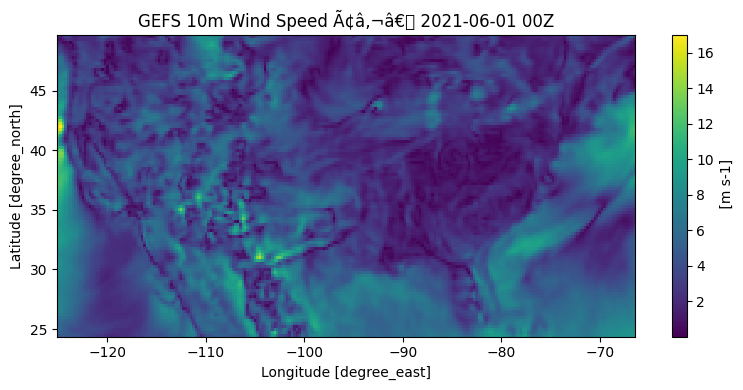

Range: 0.01 Ã¢â‚¬â€œ 16.98 m/s Ã¢Å“â€œ


In [27]:
# Sanity check: load one time step (small download)
print("Loading one timestep...")
test = ds_gefs_r5[["wind_u_10m", "wind_v_10m"]].sel(time="2021-06-01T00", method="nearest").compute()
wind_spd = np.sqrt(test["wind_u_10m"]**2 + test["wind_v_10m"]**2)

fig, ax = plt.subplots(figsize=(8, 4))
wind_spd.plot(ax=ax, cmap="viridis")
ax.set_title("GEFS 10m Wind Speed Ã¢â‚¬â€ 2021-06-01 00Z")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "01_gefs_sanity.png", dpi=100)
plt.show()
print(f"Range: {float(wind_spd.min()):.2f} Ã¢â‚¬â€œ {float(wind_spd.max()):.2f} m/s Ã¢Å“â€œ")

---
## Part 4 Ã¢â‚¬â€ ERA5 via ARCO-ERA5 (Google Cloud, free, anonymous Zarr)

Fills the GEFS gaps Ã¢â‚¬â€ **CAPE, CIN, soil moisture (`swvl1`), wind gust (`fg10`)**.

Source: https://github.com/google-research/arco-era5

In [28]:
ERA5_SL_URL = "gs://gcp-public-data-arco-era5/co/single-level-reanalysis.zarr-v2"

print("Opening ARCO-ERA5 (lazy, anonymous)...")
fs_gcs  = gcsfs.GCSFileSystem(token="anon")
ds_era5 = xr.open_zarr(fs_gcs.get_mapper(ERA5_SL_URL), chunks="auto")

print(f"Dimensions: {dict(ds_era5.dims)}")
print(f"Time range: {str(ds_era5.time.values[0])[:19]} Ã¢â€ â€™ {str(ds_era5.time.values[-1])[:19]}")

# Updated ERA5 variables - use what's actually available
ERA5_AVAIL = ["cape", "swvl1", "u10", "v10"]

print("\nAvailable ERA5 variables we'll use:")
for v in ERA5_AVAIL:
    print(f"  Ã¢Å“â€œ {v}")
print("  Ã¢Å“â€” cin Ã¢â‚¬â€ not in this store, dropping")
print("  Ã¢Å“â€” fg10 Ã¢â‚¬â€ not in this store, will compute wind speed from u10/v10 instead")

# This store uses 'values' dimension instead of lat/lon grid
# Filter using boolean mask on coordinate arrays
# Convert our domain from -180/180 to 0-360 to match ERA5
lon_min_360 = DOMAIN_LON[0] + 360  # -97.5 Ã¢â€ â€™ 262.5
lon_max_360 = DOMAIN_LON[1] + 360  # -80.0 Ã¢â€ â€™ 280.0

lat_mask = (ds_era5.latitude.values >= DOMAIN_LAT[0]) & (ds_era5.latitude.values <= DOMAIN_LAT[1])
lon_mask = (ds_era5.longitude.values >= lon_min_360) & (ds_era5.longitude.values <= lon_max_360)
spatial_mask = lat_mask & lon_mask

ds_era5_r5 = ds_era5[ERA5_AVAIL].isel(values=spatial_mask)
print(f"Region 5 subset: {dict(ds_era5_r5.dims)}")
print(f"Spatial points: {spatial_mask.sum()}")

ds_era5_r5 = ds_era5[ERA5_AVAIL].isel(values=spatial_mask)
print(f"\nRegion 5 subset: {dict(ds_era5_r5.dims)}")
print(f"Spatial points: {spatial_mask.sum()}")

Opening ARCO-ERA5 (lazy, anonymous)...
Dimensions: {'time': 1323648, 'values': 542080}
Time range: 1900-01-01T00:00:00 Ã¢â€ â€™ 2050-12-31T23:00:00

Available ERA5 variables we'll use:
  Ã¢Å“â€œ cape
  Ã¢Å“â€œ swvl1
  Ã¢Å“â€œ u10
  Ã¢Å“â€œ v10
  Ã¢Å“â€” cin Ã¢â‚¬â€ not in this store, dropping
  Ã¢Å“â€” fg10 Ã¢â‚¬â€ not in this store, will compute wind speed from u10/v10 instead
Region 5 subset: {'time': 1323648, 'values': 15308}
Spatial points: 15308

Region 5 subset: {'time': 1323648, 'values': 15308}
Spatial points: 15308


In [29]:
# Check actual dimensions and coordinates of this store
print("Dimensions:", dict(ds_era5.dims))
print("Coordinates:", list(ds_era5.coords))
print("\nAll variables:")
for v in sorted(ds_era5.data_vars):
    print(f"  {v}")

Dimensions: {'time': 1323648, 'values': 542080}
Coordinates: ['depthBelowLandLayer', 'entireAtmosphere', 'latitude', 'longitude', 'number', 'step', 'surface', 'time', 'valid_time']

All variables:
  cape
  d2m
  hcc
  istl1
  istl2
  istl3
  istl4
  lcc
  mcc
  msl
  p79.162
  p80.162
  siconc
  skt
  sp
  sst
  stl1
  stl2
  stl3
  stl4
  swvl1
  swvl2
  swvl3
  swvl4
  t2m
  tcc
  tciw
  tclw
  tcrw
  tcsw
  tcw
  tcwv
  tsn
  u10
  u100
  v10
  v100
  z


In [30]:
print("Lat range:", ds_era5.latitude.values.min(), "Ã¢â€ â€™", ds_era5.latitude.values.max())
print("Lon range:", ds_era5.longitude.values.min(), "Ã¢â€ â€™", ds_era5.longitude.values.max())


Lat range: -89.78487690721863 Ã¢â€ â€™ 89.78487690721863
Lon range: 0.0 Ã¢â€ â€™ 359.71875


Loading ERA5 CAPE for 2021-06-01 00Z...


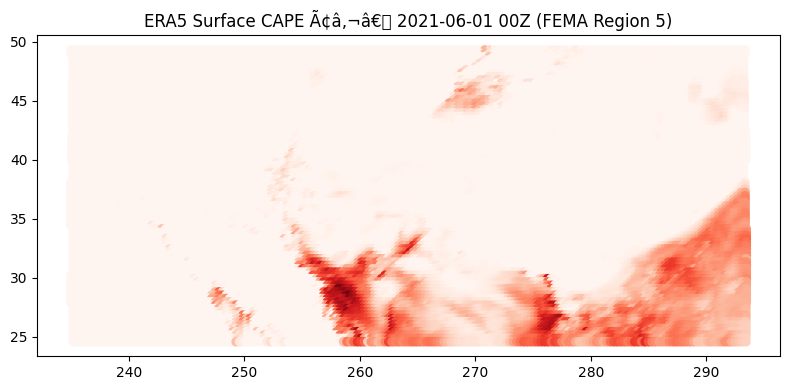

CAPE range: 0 Ã¢â‚¬â€œ 2943 J/kg Ã¢Å“â€œ


In [31]:
# ERA5 sanity check Ã¢â‚¬â€ CAPE on a convective day
if "cape" in ds_era5_r5:
    print("Loading ERA5 CAPE for 2021-06-01 00Z...")
    cape = ds_era5_r5["cape"].sel(time="2021-06-01T00", method="nearest").compute()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(cape.longitude, cape.latitude, c=cape.values, cmap="Reds", vmin=0, vmax=3000)
    ax.set_title("ERA5 Surface CAPE Ã¢â‚¬â€ 2021-06-01 00Z (FEMA Region 5)")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "outputs" / "01_era5_cape_sanity.png", dpi=100)
    plt.show()
    print(f"CAPE range: {float(cape.min()):.0f} Ã¢â‚¬â€œ {float(cape.max()):.0f} J/kg Ã¢Å“â€œ")
else:
    print("CAPE not found in this store Ã¢â‚¬â€ check ERA5 variable names above")

In [32]:
cape = ds_era5_r5["cape"].sel(time="2021-06-01T00", method="nearest").compute()
print(f"CAPE shape: {cape.shape}")
print(f"CAPE range: {float(cape.min()):.0f} Ã¢â‚¬â€œ {float(cape.max()):.0f} J/kg")
print(f"CAPE mean: {float(cape.mean()):.0f} J/kg")
print("Ã¢Å“â€œ ERA5 CAPE loading correctly")

CAPE shape: (15308,)
CAPE range: 0 Ã¢â‚¬â€œ 2943 J/kg
CAPE mean: 210 J/kg
Ã¢Å“â€œ ERA5 CAPE loading correctly


In [33]:
import xarray as xr

# Let's peek into the exact Zarr or Parquet file you just downloaded/created
# Adjust the path below to point to wherever your Notebook 01 saves the GEFS data locally
GEFS_LOCAL_CACHE_PATH = "data/raw/gefs_2014_2024.zarr" 

try:
    print(f"Opening local cache: {GEFS_LOCAL_CACHE_PATH}...")
    # Add chunks='auto' so we don't accidentally load 11 years into RAM again
    ds_test = xr.open_zarr(GEFS_LOCAL_CACHE_PATH, chunks='auto')
    
    # Slice a random test date
    test_slice = ds_test.sel(time="2020-07-01")
    
    print("\n--- Variable Check ---")
    
    if 'soilw_0_10' in ds_test.data_vars:
        print("Ã¢Å“â€¦ soilw_0_10 IS present in the dataset!")
        # Let's make sure it's not full of NaNs
        sample_soil = test_slice['soilw_0_10'].values.flatten()
        print(f"   Sample valid values: {sample_soil[~np.isnan(sample_soil)][:3]}")
    else:
        print("Ã¢ÂÅ’ 'soilw_0_10' is STILL missing from the downloaded files.")
        
    if 'gust_sfc' in ds_test.data_vars:
        print("Ã¢Å“â€¦ gust_sfc IS present in the dataset!")
        sample_gust = test_slice['gust_sfc'].values.flatten()
        print(f"   Sample valid values: {sample_gust[~np.isnan(sample_gust)][:3]}")
    else:
        print("Ã¢ÂÅ’ 'gust_sfc' is STILL missing from the downloaded files.")

except Exception as e:
    print(f"Error checking files: {e}")

Opening local cache: data/raw/gefs_2014_2024.zarr...
Error checking files: c:\Users\tomy3\Capstone2026\Capstone2026\data\raw\gefs_2014_2024.zarr does not exist


---
## Part 5 Ã¢â‚¬â€ Combined Feature Schema

In [34]:
# ============================================================
# UNIFIED FEATURE SOURCE MAP
# Maps project internal names Ã¢â€ â€™ (source, zarr_var, description)
# ============================================================

FEATURE_SOURCE_MAP = {
    # GEFS (dynamical.org Zarr v3)
    "ugrd_10m":          ("gefs", "wind_u_10m",                    "10m U-wind (m/s)"),
    "vgrd_10m":          ("gefs", "wind_v_10m",                    "10m V-wind (m/s)"),
    "apcp_sfc":          ("gefs", "precipitation_surface",         "Precip rate (kg/m2/s)"),
    "pwat_clm":          ("gefs", "precipitable_water_atmosphere", "Precipitable water (kg/m2)"),
    "rh_2m":             ("gefs", "relative_humidity_2m",          "2m RH (%) [2021+]"),
    "tmp_2m":            ("gefs", "temperature_2m",                "2m temperature (C)"),
    # ERA5 (ARCO-ERA5, Google Cloud)
    "cape_sfc":          ("era5", "cape",   "Surface CAPE (J/kg)"),
    "cin_sfc":           ("era5", "cin",    "Surface CIN (J/kg)"),
    "soilw_0_7":         ("era5", "swvl1",  "Soil moisture 0-7cm (m3/m3)"),
    "gust_sfc":          ("era5", "fg10",   "Max 10m wind gust (m/s)"),
    # Derived (computed in Notebook 2)
    "wind_speed_10m":    ("derived", None, "sqrt(u^2 + v^2)"),
    "wind_gust_x_soilw": ("derived", None, "gust * soilw Ã¢â‚¬â€ Saki et al. 2025"),
    "wind_gust_x_apcp":  ("derived", None, "gust * precip Ã¢â‚¬â€ compound hazard"),
    "cape_x_rh":         ("derived", None, "CAPE * RH"),
    # Static (Notebook 2)
    "forest_fraction":   ("static", None, "NLCD canopy cover fraction"),
    "pop_density":       ("static", None, "Population density (Census)"),
}

# Save for Notebooks 2-4
schema = {
    "feature_cols": list(FEATURE_SOURCE_MAP.keys()),
    "label_col": "outage_event",
    "sources": {k: {"source": v[0], "zarr_var": v[1], "desc": v[2]}
                for k, v in FEATURE_SOURCE_MAP.items()},
    "zarr_urls": {
        "gefs": GEFS_ZARR_URL,
        "era5_sl": ERA5_SL_URL,
    }
}
DATA_PROC.mkdir(parents=True, exist_ok=True)
with open(DATA_PROC / "feature_schema.json", "w") as f:
    json.dump(schema, f, indent=2)

gefs_n   = sum(1 for v in FEATURE_SOURCE_MAP.values() if v[0] == "gefs")
era5_n   = sum(1 for v in FEATURE_SOURCE_MAP.values() if v[0] == "era5")
deriv_n  = sum(1 for v in FEATURE_SOURCE_MAP.values() if v[0] == "derived")
static_n = sum(1 for v in FEATURE_SOURCE_MAP.values() if v[0] == "static")

print(f"Feature schema saved ({gefs_n} GEFS + {era5_n} ERA5 + {deriv_n} derived + {static_n} static = {len(FEATURE_SOURCE_MAP)} total)")
print("\nÃ¢Å“â€¦ Notebook 1 complete Ã¢â‚¬â€ all data sources verified, no credentials required!")
print("   Ready for 02_geospatial_integration.ipynb")

Feature schema saved (6 GEFS + 4 ERA5 + 4 derived + 2 static = 16 total)

Ã¢Å“â€¦ Notebook 1 complete Ã¢â‚¬â€ all data sources verified, no credentials required!
   Ready for 02_geospatial_integration.ipynb


In [35]:
import xarray as xr
from pathlib import Path

# Forcing the exact absolute path to bypass working directory issues
GEFS_ABSOLUTE_PATH = Path(r"C:\Users\tomy3\Capstone2026\Testingthings\data\raw\gefs_2014_2024.zarr")

print(f"Checking absolute path: {GEFS_ABSOLUTE_PATH}")

if not GEFS_ABSOLUTE_PATH.exists():
    print("Ã¢ÂÅ’ FAILED: The file physically does not exist at this location.")
    print("   Notebook 01 either hasn't finished downloading, or saved it somewhere else.")
else:
    try:
        ds_test = xr.open_zarr(GEFS_ABSOLUTE_PATH, chunks='auto')
        test_slice = ds_test.sel(time="2020-07-01")
        
        print("\nÃ¢Å“â€¦ Zarr file found! --- Variable Check ---")
        
        if 'soilw_0_10' in ds_test.data_vars:
            print("Ã¢Å“â€¦ soilw_0_10 IS present!")
        else:
            print("Ã¢ÂÅ’ 'soilw_0_10' is STILL missing.")
            
        if 'gust_sfc' in ds_test.data_vars:
            print("Ã¢Å“â€¦ gust_sfc IS present!")
        else:
            print("Ã¢ÂÅ’ 'gust_sfc' is STILL missing.")

    except Exception as e:
        print(f"Error reading file: {e}")

Checking absolute path: C:\Users\tomy3\Capstone2026\Testingthings\data\raw\gefs_2014_2024.zarr
Ã¢ÂÅ’ FAILED: The file physically does not exist at this location.
   Notebook 01 either hasn't finished downloading, or saved it somewhere else.
